# Inference Notebook


In [51]:
from google.colab import drive

drive.mount('/content/drive')
%cd /content/drive/MyDrive/NER/Inference

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/NER/Inference


In [53]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertConfig, BertForTokenClassification

## Reading Data

In [70]:
import os
dfs=[]
for file in os.listdir('Inference_data'):
  if file.endswith('.jsonl'):
    cur_df=pd.read_json('Inference_data/'+file,lines=True)
    dfs.append(cur_df)

inf_df=pd.concat(dfs)

In [71]:
inf_df.head()

,source_file,page,sentence
0,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,2,աեղիսկողոս սեսոյ ատճյան նյու ոֆ բուօհաուզեն վի...
1,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,կ հայ մշակույթի հուշարձանները խորհրդային ադրբե...
2,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,հհ գաս գիտություն հրատ
3,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,գիրքը նվիոված է թվականից ի վեր բայց հատկաղես թ...
4,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,տեւական մի շար ճամփուդությունների շնորհիվ կուտ...


In [5]:
inf_df.describe()

,page
count,26319.000000
mean,184.889471
std,152.837033
min,1.000000
25%,51.000000
50%,146.000000
75%,284.500000
max,490.000000


## Model Loading

In [6]:
from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'
print(device)

cuda


In [7]:
labels_to_ids = {k: v for v, k in enumerate(['O','B-INSC','I-INSC'])}
ids_to_labels = {v: k for v, k in enumerate(['O','B-INSC','I-INSC'])}
labels_to_ids

{'O': 0, 'B-INSC': 1, 'I-INSC': 2}

In [8]:
import torch
from transformers import BertTokenizerFast, BertForTokenClassification

tokenizer = BertTokenizerFast.from_pretrained("bert-base-multilingual-uncased")

model = BertForTokenClassification.from_pretrained(
    "bert-base-multilingual-uncased",
    num_labels=len(labels_to_ids)
)

state_dict = torch.load("Copy of progressive_final.pt", map_location="cpu")
model.load_state_dict(state_dict)
model.eval()
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-1

## Inference


In [19]:
def ner_predict(sentence):
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, max_length=512)

    # Move tensors to GPU/CPU depending on the model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits

    pred_ids = torch.argmax(logits, dim=2).squeeze().tolist()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"].squeeze().tolist())

    pred_labels = [ids_to_labels[i] for i in pred_ids]
    return list(zip(tokens, pred_labels))

In [17]:
from tqdm import tqdm
tqdm.pandas()

inf_df['NER']=inf_df['sentence'].apply(ner_predict)

AttributeError: 'dict' object has no attribute 'word_ids'

## Analysis

In [18]:
inf_df.head()

,source_file,page,sentence,NER
0,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,2,աեղիսկողոս սեսոյ ատճյան նյու ոֆ բուօհաուզեն վի...,"[([CLS], O), (ա, O), (##եղ, O), (##իս, O), (##..."
1,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,կ հայ մշակույթի հուշարձանները խորհրդային ադրբե...,"[([CLS], O), (կ, O), (հայ, O), (մշակույթի, O),..."
2,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,հհ գաս գիտություն հրատ,"[([CLS], O), (հհ, O), (գ, O), (##աս, O), (գ, O..."
3,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,գիրքը նվիոված է թվականից ի վեր բայց հատկաղես թ...,"[([CLS], O), (գ, O), (##ի, O), (##ր, O), (##քը..."
4,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,տեւական մի շար ճամփուդությունների շնորհիվ կուտ...,"[([CLS], O), (տ, O), (##եւ, O), (##ական, O), (..."


In [21]:
def merge_wordpieces_from_ner_list(ner_list):
    """
    ner_list: a list of tuples [(token, label), ...] containing WordPiece tokens.
    Returns merged full words with their labels: [(word, label), ...]
    """
    merged = []
    current_word = ""
    current_label = None

    for token, label in ner_list:
        if token in ["[CLS]", "[SEP]"]:
            continue

        if token.startswith("##"):
            # continuation subword
            current_word += token[2:]
        else:
            # starting a new word → flush the previous one
            if current_word:
                merged.append((current_word, current_label))
            current_word = token
            current_label = label

    # add last word
    if current_word:
        merged.append((current_word, current_label))

    return merged


In [38]:
ner_df=inf_df.copy()
ner_df['NER']=ner_df['NER'].apply(merge_wordpieces_from_ner_list)

In [39]:
ner_df.head()

,source_file,page,sentence,NER
0,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,2,աեղիսկողոս սեսոյ ատճյան նյու ոֆ բուօհաուզեն վի...,"[(աեղիսկողոս, O), (սեսոյ, O), (ատճյան, O), (նյ..."
1,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,կ հայ մշակույթի հուշարձանները խորհրդային ադրբե...,"[(կ, O), (հայ, O), (մշակույթի, O), (հուշարձանն..."
2,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,հհ գաս գիտություն հրատ,"[(հհ, O), (գաս, O), (գիտություն, O), (հրատ, O)]"
3,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,գիրքը նվիոված է թվականից ի վեր բայց հատկաղես թ...,"[(գիրքը, O), (նվիոված, O), (է, O), (թվականից, ..."
4,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,տեւական մի շար ճամփուդությունների շնորհիվ կուտ...,"[(տեւական, O), (մի, O), (շար, O), (ճամփուդությ..."


In [40]:
def extract_inscriptions_grouped(ner_list):
    """
    Extract contiguous spans where label != 'O',
    and merge words of each span into one string.
    """
    results = []
    current = []

    for word, label in ner_list:
        if label != "O":
            # add word to current span
            current.append(word)
        else:
            # flush current span
            if current:
                results.append(" ".join(current))
                current = []

    # flush last span
    if current:
        results.append(" ".join(current))

    return results


In [41]:
ner_df['term']=ner_df['NER'].apply(extract_inscriptions_grouped)

In [42]:
ner_df.head()

,source_file,page,sentence,NER,term
0,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,2,աեղիսկողոս սեսոյ ատճյան նյու ոֆ բուօհաուզեն վի...,"[(աեղիսկողոս, O), (սեսոյ, O), (ատճյան, O), (նյ...",[]
1,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,կ հայ մշակույթի հուշարձանները խորհրդային ադրբե...,"[(կ, O), (հայ, O), (մշակույթի, O), (հուշարձանն...",[]
2,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,հհ գաս գիտություն հրատ,"[(հհ, O), (գաս, O), (գիտություն, O), (հրատ, O)]",[]
3,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,գիրքը նվիոված է թվականից ի վեր բայց հատկաղես թ...,"[(գիրքը, O), (նվիոված, O), (է, O), (թվականից, ...",[]
4,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,3,տեւական մի շար ճամփուդությունների շնորհիվ կուտ...,"[(տեւական, O), (մի, O), (շար, O), (ճամփուդությ...",[]


In [43]:
extractions=ner_df[ner_df['term'].apply(len)>0]

## Extraction Analysis

In [44]:
extractions

,source_file,page,sentence,NER,term
352,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,20,հետեւաբար որպեսզի գոնե մասամբ լրացրած լինենք ա...,"[(հետեւաբար, O), (որպեսզի, O), (գոնե, O), (մաս...",[վիմագիր]
398,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,22,իրոք՝ բարեբախտաբար քանի որ նրան վիճակվեց այդտե...,"[(իրոք, O), (՝, O), (բարեբախտաբար, O), (քանի, ...",[վիմագրերի]
411,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,23,արշավախմբի մասնագիտական ուղվածությունը խիստ նպ...,"[(արշավախմբի, O), (մասնագիտական, O), (ուղվածու...",[վիմագրերի]
421,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,23,սկսած թ ից երբ առաջին անգամ հնարավորություն ու...,"[(սկսած, O), (թ, O), (ից, O), (երբ, O), (առաջի...",[վիմագրերի]
438,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,24,ցավոք մինչեւ տարածքի ազատագրումը թթ թուրքերը հ...,"[(ցավոք, O), (մինչեւ, O), (տարածքի, O), (ազատա...",[վիմագիր]
...,...,...,...,...,...
587,ՊԱՏՄԱՄՇԱԿՈՒԹԱՅԻՆ ԺԱՌԱՆԳՈՒԹՅՈՒՆ ՄԱՏԵՆԱՇԱՐ.txt,49,վահրամ անունով գործիչ նույնպես հայտնի է եկեղեց...,"[(վահրամ, O), (անունով, O), (գործիչ, O), (նույ...",[վիմագրերից]
596,ՊԱՏՄԱՄՇԱԿՈՒԹԱՅԻՆ ԺԱՌԱՆԳՈՒԹՅՈՒՆ ՄԱՏԵՆԱՇԱՐ.txt,49,սարգսեան գ վիմագրագիտական նորոյթներ,"[(սարգսեան, O), (գ, O), (վիմագրագիտական, B-INS...",[վիմագրագիտական]
654,ՊԱՏՄԱՄՇԱԿՈՒԹԱՅԻՆ ԺԱՌԱՆԳՈՒԹՅՈՒՆ ՄԱՏԵՆԱՇԱՐ.txt,56,դրանց բարձրորակ նմուշները պատրաստված են երկփեղ...,"[(դրանց, O), (բարձրորակ, O), (նմուշները, O), (...",[վիմագիր]
1186,ՊԱՏՄԱՄՇԱԿՈՒԹԱՅԻՆ ԺԱՌԱՆԳՈՒԹՅՈՒՆ ՄԱՏԵՆԱՇԱՐ.txt,110,ծերեթյան կ հայ վիմագրագիտության և դրամագիտությ...,"[(ծերեթյան, O), (կ, O), (հայ, O), (վիմագրագիտո...",[վիմագրագիտության]


In [45]:
flat_df = extractions.explode("term").reset_index(drop=True)


In [46]:
flat_df.head()

,source_file,page,sentence,NER,term
0,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,20,հետեւաբար որպեսզի գոնե մասամբ լրացրած լինենք ա...,"[(հետեւաբար, O), (որպեսզի, O), (գոնե, O), (մաս...",վիմագիր
1,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,22,իրոք՝ բարեբախտաբար քանի որ նրան վիճակվեց այդտե...,"[(իրոք, O), (՝, O), (բարեբախտաբար, O), (քանի, ...",վիմագրերի
2,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,23,արշավախմբի մասնագիտական ուղվածությունը խիստ նպ...,"[(արշավախմբի, O), (մասնագիտական, O), (ուղվածու...",վիմագրերի
3,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,23,սկսած թ ից երբ առաջին անգամ հնարավորություն ու...,"[(սկսած, O), (թ, O), (ից, O), (երբ, O), (առաջի...",վիմագրերի
4,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,24,ցավոք մինչեւ տարածքի ազատագրումը թթ թուրքերը հ...,"[(ցավոք, O), (մինչեւ, O), (տարածքի, O), (ազատա...",վիմագիր


In [49]:
flat_df['term'].unique()

array(['վիմագիր', 'վիմագրերի', 'տապանագրի', 'վիմագի',
       'նվիրատվական արձանագրություններից', 'եկեղեցու բարավորի արձանագիր',
       'վիմագրի', 'տինաւարական', 'վիմագրեր', 'վիմագքի',
       'օինարարական արձանագրությունից', 'շինարարական',
       'նվիրատվական արձանագրությունից', 'շինարարական արձանագրության',
       'արձանագրություն', 'վիմագրարի', 'վիմագրաի', 'բարավորի',
       'վիմագրերում', 'վիմագրեի', 'վիմագրից', 'հիշատակագիր',
       'նվիրատվական', 'ժամատան արձանագրությունները',
       'շինարարական արձանագրությունը',
       'վիմագիրևայսօրէլամբողջոթյամբրևթեոևելի', 'շինաւարական',
       'վիմագրերից', 'վիմագերի', 'վիմագիրը', 'վիմագերն', 'վիմագիրն',
       'վիմագրում', 'ինարարական արձանագրության', 'տապանագրերը',
       'եկեղեցու', 'նվիրատվական արձանագրության', 'տապանագիրը',
       'վիմագրություններ', 'տապանագրից', 'վիմական',
       'շինարարական արձանագրութիւնն', 'վիմագրիչները', 'վիմագրագէտ',
       'տապանագրերի', 'տապանագրում', 'վիմական արձանագրութիւններըը',
       'վիմագրին', 'շինարարակ

In [50]:
flat_df.to_csv('Inferences.csv')

## Statistics

In [54]:
train_data = pd.read_csv('/content/drive/MyDrive/NER/data/train_complete_doctored_V2.csv')
eval_data = pd.read_csv('/content/drive/MyDrive/NER/data/eval_ner_doctored_v2.csv')
test_data = pd.read_csv('/content/drive/MyDrive/NER/data/test_ner_doctored_v2.csv')
inference_data=pd.read_csv('Inferences.csv')

In [62]:
train_data.columns,eval_data.columns,test_data.columns

(Index(['sentence', 'term', 'page_number', 'file_name', 'word', 'tag',
        'word_labels'],
       dtype='object'),
 Index(['sentence', 'term', 'word', 'tag', 'word_labels'], dtype='object'),
 Index(['sentence', 'term', 'word', 'tag', 'word_labels'], dtype='object'))

In [65]:
used_data=pd.concat([train_data[['sentence','term']],eval_data[['sentence','term']],test_data[['sentence','term']]],ignore_index=True)

In [68]:
used_data['term']=used_data['term'].replace('NaN',pd.NA)
used_data

,sentence,term
0,հայկական սսռ գիտությունների ակադեմիայի պատմութ...,Վիմագիր
1,ցահկեր ցանկ վիմական արձանադրությունների մեջ գո...,վիմական արձանադրությունների
2,գլուղի կենարոնում կա նաև մի փոքրիկ թաղածածկ եկ...,տապանաքարային արձանագրություն
3,արևելյան եղրի գերեզմանատան մեջ՝ իրար կողքի որո...,Գերեզմանատան արձանագրություն
4,շինարարական արձանագրությունների բացակալության ...,շինարարական արձանագրությունների
...,...,...
51758,գրրածա ուրարտական պետության կացձում,NaN
51759,թագավորական կամուրջ բանդիվան գյուղում թալին թա...,NaN
51760,թաղք գյուղ արթիկի մերծակայքում որը նվիրաբերվել...,NaN
51761,իլխինապ իլխիաբ իլխիաբի գյուղ ալեքսանդրապոլի գա...,NaN


In [117]:
complete_inference=inf_df.merge(inference_data,on=['sentence','page','source_file'],how='left')[['sentence','page','source_file','term']]
complete_inference.head()

,sentence,page,source_file,term
0,աեղիսկողոս սեսոյ ատճյան նյու ոֆ բուօհաուզեն վի...,2,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,NaN
1,կ հայ մշակույթի հուշարձանները խորհրդային ադրբե...,3,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,NaN
2,հհ գաս գիտություն հրատ,3,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,NaN
3,գիրքը նվիոված է թվականից ի վեր բայց հատկաղես թ...,3,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,NaN
4,տեւական մի շար ճամփուդությունների շնորհիվ կուտ...,3,ՀԱՅ-ՄՇԱԿՈՒՅԹԻ-ՀՈՒՇԱՐՁԱՆՆԵՐԸ-ԽՈՐՀՐԴԱՅԻՆ-ԱԴՐԲԵՋԱ...,NaN


In [119]:
complete_inference.to_csv('complete_inference.csv')

Figure saved to: images/Infered_vs_Development_data_split.0.png


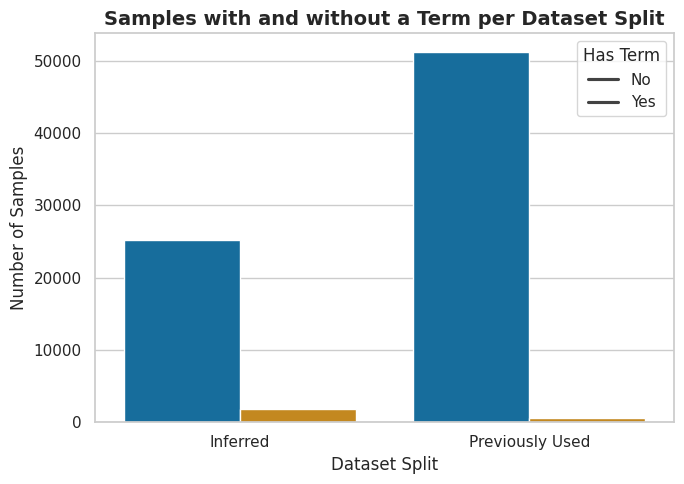

In [130]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

used_data["split"] = "Previously Used"
complete_inference["split"] = "Inferred"
data_all = pd.concat([used_data,complete_inference[['sentence','term','split']]], ignore_index=True)

# Determine if each row has a non-null term
data_all["has_term"] = data_all["term"].notna()
summary = (
    data_all.groupby(["split", "has_term"])
    .size()
    .reset_index(name="count")
)

summary_pivot = summary.pivot(index="split", columns="has_term", values="count").fillna(0)
summary_pivot.columns = ["No Term", "Has Term"]
summary_pivot["Total"] = summary_pivot.sum(axis=1)
summary_pivot = summary_pivot.astype(int).reset_index()

sns.set_theme(style="whitegrid", palette="colorblind")
plt.figure(figsize=(7, 5))
sns.barplot(data=summary, x="split", y="count", hue="has_term")


plt.title("Samples with and without a Term per Dataset Split", fontsize=14, weight="bold")
plt.xlabel("Dataset Split", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.legend(title="Has Term", labels=["No", "Yes"])
plt.tight_layout()

os.makedirs("images", exist_ok=True)
plot_path = "images/Infered_vs_Development_data_split.0.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

print(f"Figure saved to: {plot_path}")

plt.show()

In [131]:
seen_data_terms=set(used_data['term'].dropna().apply(lambda x: x.lower()))
new_data_terms=set(complete_inference['term'].dropna().apply(lambda x: x.lower()))

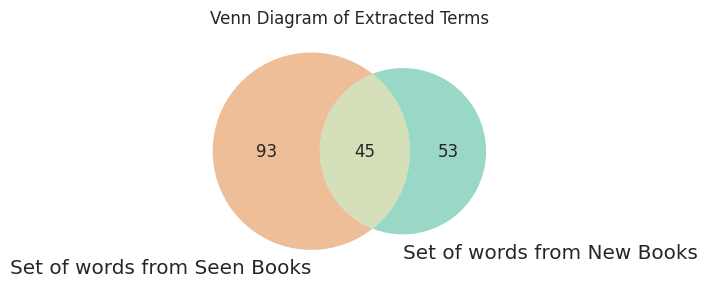

In [137]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt


plt.figure(figsize=(6, 4))

venn2([seen_data_terms, new_data_terms], set_labels=("Set of words from Seen Books", "Set of words from New Books"))
plt.title("Venn Diagram of Extracted Terms")
plt.tight_layout()
plot_path = "images/Ven_of_extracted_terms.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
